## NÁVOD:
## POSTUP:
1. Upravujte jen buňky nad nimiž je napsáno "měnit":)
2. Nastavte parametry
3. Klikněte na "Spustit vše" (nebo "Run all") nahoře
4. (Při prvním spuštění potvrďte případná oprávnění Colabu.)
5. Počkejte než program doběhne
6. Úplně dole (scrolujte) se vykreslí kartogram.  

## MĚNIT - Nastavte parametry

In [15]:
# medián nebo průměr
SELECTED_STAT_METHOD = "medián"

# Zvol scénář: modifikace vstupních dat do kartogramu. Zadáváme v %.
MY_PERCENTAGE_SCENARIO = 50

# Zvol kategorii priority dle seznamu o buňku níže
SELECTED_PRIORITY_CATEGORY = "ALL"

# Zvol typ lokality dle seznamu o 2 buňky níže
SELECTED_LOCALITY_TYPE = "ALL"

# počítat inflaci k roku
YEAR_TO_COUNT_INFLATION = 2025

#### Kategorie priority:
1. ALL = všechny kategorie
2. A_ALL = [A1.0, A1.1, A1.2, A1.3, A2.0, A2.1, A2.2, A2.3, A3.1, A3.2, A3.3]
3. A1 = [A1.0, A1.1, A1.2, A1.3]
4. A2 = [A2.0, A2.1, A2.2, A2.3]
5. A3 = [A3.1, A3.2, A3.3]
6. P1+P2 = [P1.0, P1.1, P1.2, P1.3, P2.0, P2.1, P2.2, P2.3]
7. P3+P4 = [P3.0, P3.1, P3.2, P3.3, P4.0, P4.1, P4.2, P4.3]
8. N = [N0.0, N0.1, N0.2, N1.0, N1.1, N1.2, N2.0, N2.1, N2.2, N2.3]

# -------------------------------------------------------------------------------

## DÁL NIC NEMĚNIT

### Stáhne repo

In [16]:
import os

repo = "/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab"

if os.path.exists(repo):
    %cd $repo
    !git pull
else:
    !git clone https://github.com/matejpiro/CENIA_suchanek_kontaminovana_mista_na_Google_colab.git
    %cd $repo

/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 9.28 MiB | 7.60 MiB/s, done.
From https://github.com/matejpiro/CENIA_suchanek_kontaminovana_mista_na_Google_colab
   d550524..62f3a66  main       -> origin/main
Updating d550524..62f3a66
Fast-forward
 ..._vylou\304\215en\303\275ch_05022026_Matej.xlsx" | Bin 9751709 -> 9753525 bytes
 1 file changed, 0 insertions(+), 0 deletions(-)


### Pevné parametry


In [17]:
MY_SELECTED_CLASSIFICATION = "typ původce znečištění" # 1) typ původce znečištění, 2) typ lokality, 3) typ prací

# wanna save simplified excel with inflation data?  # --- to desktop (1 = save, everything else = dont save)
SAVE_EXCEL_INFLATION = 0

PRINT_VALUES_FOR_KRAJ = True # print values for Kraj in the cartogram

# Do I save cartograms?
SAVE_CARTOGRAMS = False

### Spustí kod

In [18]:
RUN_CARTOGRAM = False

%run Kontaminovana_mista_analyza.ipynb

fatal: destination path 'CENIA_suchanek_kontaminovana_mista_na_Google_colab' already exists and is not an empty directory.


/tmp/ipykernel_2796/1140269721.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_DF_selected_1["cena_diff_(Kc)"] = my_DF_selected_1[my_inflation_col] - my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]
/tmp/ipykernel_2796/1140269721.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_DF_selected_1["cena_diff_(%)"] = (((my_DF_selected_1[my_inflation_col] / my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]) * 100) - 100).round(1)


No excel for you now


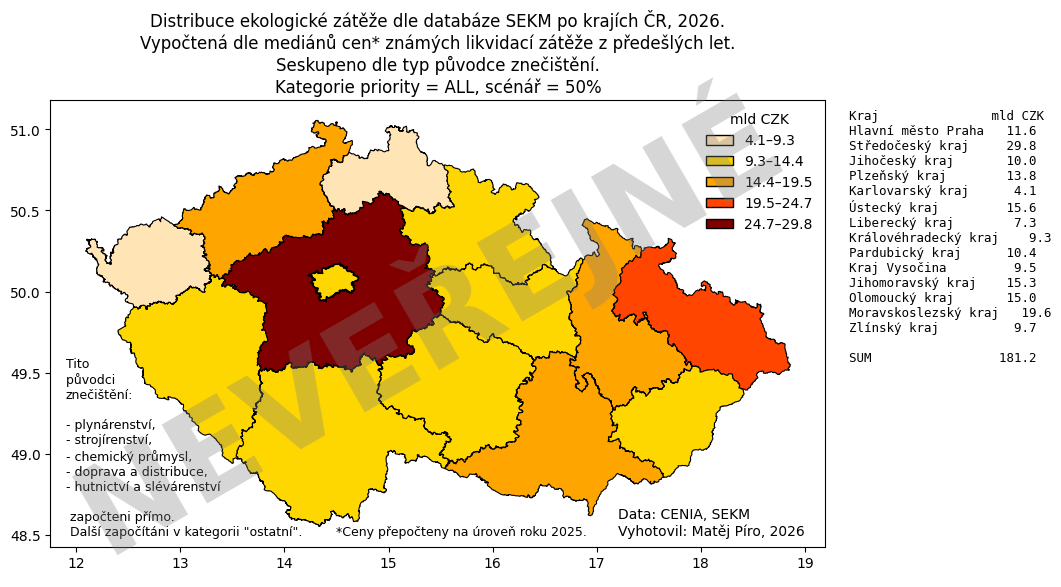

In [19]:
create_kraje_cartogram(
    my_geo_kraje_df,
    my_colors_list,
    SELECTED_STAT_METHOD,
    text_1_dict,
    text_2_dict,
    text_3_dict,
    MY_PERCENTAGE_SCENARIO,
    watermark=True, watermark_text="NEVEŘEJNÉ",
    save=SAVE_CARTOGRAMS
)